# Rotten Tomatoes Sentiment Analysis

This notebook converts the assignment into a step-by-step workflow:
- load the Rotten Tomatoes dataset,
- apply a pre-trained Hugging Face sentiment analysis model,
- evaluate predictions on the first 1000 training samples using qualitative and quantitative analysis.

## 1. Install and Import Dependencies

We import the libraries needed for dataset loading, model inference, evaluation, tabular inspection, and plotting.

In [10]:
# If you are running in a fresh environment, uncomment the next line:
# !pip install -q datasets transformers scikit-learn pandas matplotlib

from datasets import load_dataset # This is used to load the Rotten Tomatoes dataset from Hugging Face Datasets
from transformers import pipeline # This is used to create a sentiment analysis pipeline using a pre-trained model
from sklearn.metrics import (
    accuracy_score, # This is used to calculate the accuracy of the model
    classification_report, # This is used to generate a detailed classification report
    confusion_matrix, # This is used to compute the confusion matrix
    ConfusionMatrixDisplay, # This is used to display the confusion matrix
)
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## 2. Load and Inspect the Rotten Tomatoes Dataset

This uses the provided starter code to confirm the dataset structure and fields.

In [2]:
# Load the Rotten Tomatoes dataset
dataset = load_dataset("rotten_tomatoes") # This will download and load the dataset into a Hugging Face Dataset object

# Print the dataset information
print(dataset)

# Example: Accessing the training split
train_dataset = dataset["train"]

# Print the first example in the training set
print(train_dataset[0])

# Show label names for reference
label_names = train_dataset.features["label"].names
print("Label names:", label_names)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}
Label names: ['neg', 'pos']


## 3. Prepare a 1000-Sample Training Subset

To keep inference fast and aligned with the assignment, we use the first 1000 samples from the training split.

In [3]:
subset_size = 1000
shuffled_train = train_dataset.shuffle(seed=42)
train_subset = shuffled_train.select(range(1000))

texts = train_subset["text"]
true_labels = train_subset["label"]

dataset_label_to_name = {i: name for i, name in enumerate(label_names)}

subset_df = pd.DataFrame({
    "text": texts,
    "label": true_labels,
})
subset_df["label_name"] = subset_df["label"].map(dataset_label_to_name)

print(f"Subset size: {len(train_subset)}")
subset_df.head()

texts = train_subset["text"]
true_labels = train_subset["label"]

dataset_label_to_name = {i: name for i, name in enumerate(label_names)}

subset_df = pd.DataFrame({
    "text": texts,
    "label": true_labels,
})
subset_df["label_name"] = subset_df["label"].map(dataset_label_to_name)

print(f"Subset size: {len(train_subset)}")
subset_df.head()

Subset size: 1000
Subset size: 1000


,text,label,label_name
0,. . . plays like somebody spliced random momen...,0,neg
1,michael moore has perfected the art of highly ...,1,pos
2,. . . too gory to be a comedy and too silly to...,0,neg
3,"a graceful , contemplative film that gradually...",1,pos
4,the fact that the 'best part' of the movie com...,0,neg


## 4. Load a Pre-trained Sentiment Analysis Model

We use `distilbert-base-uncased-finetuned-sst-2-english`, a common sentiment model from Hugging Face.

In [4]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_classifier = pipeline(
    "sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
)

test_text = "This movie was unexpectedly funny and heartfelt."
test_prediction = sentiment_classifier(test_text)
print("Test prediction:", test_prediction)

Test prediction: [{'label': 'POSITIVE', 'score': 0.9998703002929688}]


## 5. Run Inference on the Subset

We send the 1000 review texts through the model in batches and keep both predicted labels and confidence scores.

In [5]:
predictions = sentiment_classifier(texts, batch_size=32, truncation=True)

predicted_text_labels = [pred["label"] for pred in predictions]
confidence_scores = [pred["score"] for pred in predictions]

print(f"Generated {len(predictions)} predictions.")
predictions[:10]

Generated 1000 predictions.


[{'label': 'NEGATIVE', 'score': 0.9995707869529724},
 {'label': 'POSITIVE', 'score': 0.9998703002929688},
 {'label': 'NEGATIVE', 'score': 0.9986692667007446},
 {'label': 'POSITIVE', 'score': 0.9998307228088379},
 {'label': 'NEGATIVE', 'score': 0.9982922673225403},
 {'label': 'NEGATIVE', 'score': 0.999800980091095},
 {'label': 'NEGATIVE', 'score': 0.9997304081916809},
 {'label': 'NEGATIVE', 'score': 0.9997686743736267},
 {'label': 'NEGATIVE', 'score': 0.999581515789032},
 {'label': 'NEGATIVE', 'score': 0.9845845103263855}]

## 6. Map Predictions to Dataset Labels

The model outputs text labels such as `POSITIVE` and `NEGATIVE`, so we convert them to numeric labels matching the dataset convention.

In [6]:
model_to_dataset_label = {
    "NEGATIVE": 0,
    "POSITIVE": 1,
}

predicted_labels = [model_to_dataset_label[label] for label in predicted_text_labels]

comparison_df = pd.DataFrame({
    "text": texts,
    "true_label": true_labels,
    "predicted_label": predicted_labels,
    "predicted_sentiment": predicted_text_labels,
    "confidence": confidence_scores,
})

comparison_df["true_label_name"] = comparison_df["true_label"].map(dataset_label_to_name)
comparison_df["predicted_label_name"] = comparison_df["predicted_label"].map(dataset_label_to_name)

comparison_df.head()

,text,true_label,predicted_label,predicted_sentiment,confidence,true_label_name,predicted_label_name
0,. . . plays like somebody spliced random momen...,0,0,NEGATIVE,0.999571,neg,neg
1,michael moore has perfected the art of highly ...,1,1,POSITIVE,0.999870,pos,pos
2,. . . too gory to be a comedy and too silly to...,0,0,NEGATIVE,0.998669,neg,neg
3,"a graceful , contemplative film that gradually...",1,1,POSITIVE,0.999831,pos,pos
4,the fact that the 'best part' of the movie com...,0,0,NEGATIVE,0.998292,neg,neg


## 7. Inspect Sample Predictions

This gives a qualitative look at how the model behaves on real movie reviews.

In [7]:
sample_examples = comparison_df.sample(5, random_state=42)

for example_number, (_, row) in enumerate(sample_examples.iterrows(), start=1):
    preview = row["text"][:220].replace("\n", " ")
    print(f"Example {example_number}")
    print(f"Text: {preview}...")
    print(f"True label: {row['true_label_name']}")
    print(f"Predicted label: {row['predicted_label_name']}")
    print(f"Confidence score: {row['confidence']:.4f}")
    print("-" * 80)

Example 1
Text: on its own cinematic terms , it successfully showcases the passions of both the director and novelist byatt ....
True label: pos
Predicted label: pos
Confidence score: 0.9999
--------------------------------------------------------------------------------
Example 2
Text: with a large cast representing a broad cross-section , tavernier's film bounds along with the rat-a-tat energy of " his girl friday , " maintaining a light touch while tackling serious themes ....
True label: pos
Predicted label: pos
Confidence score: 0.9995
--------------------------------------------------------------------------------
Example 3
Text: sometimes , nothing satisfies like old-fashioned swashbuckling . and in this regard , on guard delivers ....
True label: pos
Predicted label: pos
Confidence score: 0.9921
--------------------------------------------------------------------------------
Example 4
Text: the story . . . is moldy and obvious ....
True label: neg
Predicted label: neg
Confidenc

## 8. Compute Evaluation Metrics

Now we move from qualitative inspection to quantitative evaluation using accuracy, precision, recall, and F1-score.

In [8]:
accuracy = accuracy_score(true_labels, predicted_labels)

print(f"Accuracy on the first {subset_size} training samples: {accuracy:.4f}")
print("\nClassification report:")
print(classification_report(true_labels, predicted_labels, target_names=label_names, digits=4))

num_errors = sum(t != p for t, p in zip(true_labels, predicted_labels))
print(f"Misclassified samples: {num_errors}")

Accuracy on the first 1000 training samples: 0.8810

Classification report:
              precision    recall  f1-score   support

         neg     0.9052    0.8574    0.8806       512
         pos     0.8583    0.9057    0.8814       488

    accuracy                         0.8810      1000
   macro avg     0.8817    0.8816    0.8810      1000
weighted avg     0.8823    0.8810    0.8810      1000

Misclassified samples: 119


## 9. Visualize Errors with a Confusion Matrix

A confusion matrix helps show how often the model confuses negative and positive reviews.

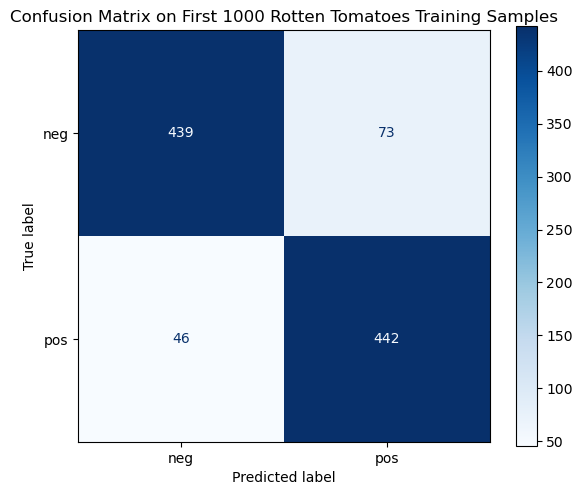

In [9]:
cm = confusion_matrix(true_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title("Confusion Matrix on First 1000 Rotten Tomatoes Training Samples")
plt.tight_layout()
plt.show()

### Interpretation of the Confusion Matrix

This updated confusion matrix shows **balanced performance across both classes**. The model correctly classified **439 negative reviews** and **442 positive reviews**, while making **73 false positive** errors (negative predicted as positive) and **46 false negative** errors (positive predicted as negative).

Overall, the model achieved an **accuracy of 0.8810 (88.10%)** on this 1000-sample subset. Since the errors are fairly limited and the correct predictions are high for both classes, the model appears to perform **consistently well on both negative and positive sentiment reviews**.